In [7]:
# cifar 10은 총 10개의 레이블로 구성된 6만장(5만장 : train / 1만장 : test의 컬러 이미지 dataset
# airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck.

import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Flatten, Input
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from tensorflow.keras.utils import to_categorical

(x_train, y_train), (x_test, y_test) = cifar10.load_data()
print(x_train.shape, y_train.shape) # (50000, 32, 32, 3) (50000, 1)
print(x_test.shape, y_test.shape) # (10000, 32, 32, 3) (10000, 1)

print(x_train[0])
print(y_train[0])

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
(50000, 32, 32, 3) (50000, 1)
(10000, 32, 32, 3) (10000, 1)
[[[ 59  62  63]
  [ 43  46  45]
  [ 50  48  43]
  ...
  [158 132 108]
  [152 125 102]
  [148 124 103]]

 [[ 16  20  20]
  [  0   0   0]
  [ 18   8   0]
  ...
  [123  88  55]
  [119  83  50]
  [122  87  57]]

 [[ 25  24  21]
  [ 16   7   0]
  [ 49  27   8]
  ...
  [118  84  50]
  [120  84  50]
  [109  73  42]]

 ...

 [[208 170  96]
  [201 153  34]
  [198 161  26]
  ...
  [160 133  70]
  [ 56  31   7]
  [ 53  34  20]]

 [[180 139  96]
  [173 123  42]
  [186 144  30]
  ...
  [184 148  94]
  [ 97  62  34]
  [ 83  53  34]]

 [[177 144 116]
  [168 129  94]
  [179 142  87]
  ...
  [216 184 140]
  [151 118  84]
  [123  92  72]]]
[6]


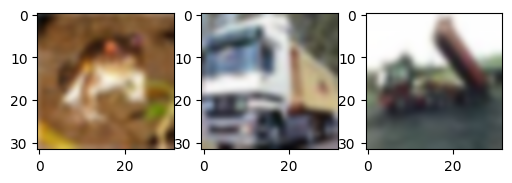

In [8]:
# 시각화 : x_train[0]
plt.figure(figsize=(6,2))
plt.subplot(131)
plt.imshow(x_train[0], interpolation='bicubic')

plt.subplot(132)
plt.imshow(x_train[1], interpolation='bicubic')

plt.subplot(133)
plt.imshow(x_train[2], interpolation='bicubic')


In [9]:
# 정규화
x_train = x_train.astype('float32') / 255
x_test = x_test.astype('float32') / 255

# 원핫인코딩
NUM_CLASSES = 10
y_train = to_categorical(y_train, num_classes=NUM_CLASSES)
y_test = to_categorical(y_test, num_classes=NUM_CLASSES)

print(y_train[0])

[0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]


In [10]:
# 모델 생성
# 실습 1 : Sequential API (CNN 없는 모델)
# model = Sequential([
#     Input(shape=(32,32,3)),
#     Flatten(),
#     Dense(256, activation='relu'),
#     Dense(128, activation='relu'),
#     Dense(NUM_CLASSES, activation='softmax')
# ])

# print(model.summary())


# 실습 1-1 : Functional API (CNN 없는 모델)
input_layer = Input(shape=(32,32,3))
x = Flatten()(input_layer)
x = Dense(256, activation='relu')(x)
x = Dense(128, activation='relu')(x)
out_layer = Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs=input_layer, outputs=out_layer)
print(model.summary())

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       786,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 820,874 (3.13 MB)

 Trainable params: 820,874 (3.13 MB)

 Non-trainable params: 0 (0.00 B)

None


In [11]:
 # model compile / fit
opti = Adam(learning_rate=0.001)
model.compile(optimizer=opti, loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(x=x_train, y=y_train, batch_size = 128, epochs=20, shuffle=True, verbose=2)

print("test acc : %.4f"%(model.evaluate(x_test, y_test, verbose=0, batch_size=128)[1]))
print("test loss : %.4f"%(model.evaluate(x_test, y_test, verbose=0, batch_size=128)[0]))


Epoch 1/20
391/391 - 7s - 17ms/step - accuracy: 0.3180 - loss: 1.9034
Epoch 2/20
391/391 - 1s - 3ms/step - accuracy: 0.3916 - loss: 1.7056
Epoch 3/20
391/391 - 1s - 3ms/step - accuracy: 0.4174 - loss: 1.6310
Epoch 4/20
391/391 - 1s - 3ms/step - accuracy: 0.4409 - loss: 1.5676
Epoch 5/20
391/391 - 1s - 3ms/step - accuracy: 0.4548 - loss: 1.5264
Epoch 6/20
391/391 - 1s - 4ms/step - accuracy: 0.4668 - loss: 1.4960
Epoch 7/20
391/391 - 2s - 4ms/step - accuracy: 0.4788 - loss: 1.4628
Epoch 8/20
391/391 - 2s - 5ms/step - accuracy: 0.4854 - loss: 1.4348
Epoch 9/20
391/391 - 1s - 3ms/step - accuracy: 0.4958 - loss: 1.4153
Epoch 10/20
391/391 - 1s - 3ms/step - accuracy: 0.5044 - loss: 1.3909
Epoch 11/20
391/391 - 1s - 3ms/step - accuracy: 0.5122 - loss: 1.3736
Epoch 12/20
391/391 - 1s - 3ms/step - accuracy: 0.5169 - loss: 1.3539
Epoch 13/20
391/391 - 1s - 3ms/step - accuracy: 0.5248 - loss: 1.3431
Epoch 14/20
391/391 - 1s - 3ms/step - accuracy: 0.5276 - loss: 1.3282
Epoch 15/20
391/391 - 1s - 3

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
예측값 :  ['dog' 'ship' 'ship' 'airplane' 'deer' 'frog' 'cat' 'frog' 'bird'
 'automobile']
실제값 :  ['cat' 'ship' 'ship' 'airplane' 'frog' 'frog' 'automobile' 'frog' 'cat'
 'automobile']
분류실패 수 :  4


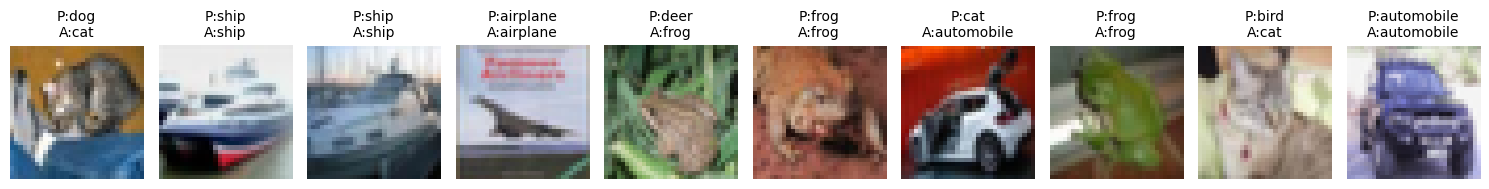

In [17]:
import numpy as np
import matplotlib.pyplot as plt

CLASSES = np.array(['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck'])

# 예측
pred_raw = model.predict(x_test[:10])
pred = CLASSES[np.argmax(pred_raw, axis=-1)]
actual = CLASSES[np.argmax(y_test[:10], axis=-1)]

print('예측값 : ', pred)
print('실제값 : ', actual)
print('분류실패 수 : ', (pred != actual).sum())

# 시각화
fig = plt.figure(figsize=(15, 3))
fig.subplots_adjust(hspace=0.4, wspace=0.4)
for i in range(10):
    img = x_test[i]
    ax = fig.add_subplot(1, 10, i + 1)
    ax.axis('off')
    ax.imshow(img)
    ax.set_title(f'P:{pred[i]}\nA:{actual[i]}', fontsize=10)

plt.tight_layout()
plt.show()

# 현재 모델은 컬러 이미지 분류에 대한 정확도가 떨어짐 (Dense만 사용)